In [107]:
!pip install shap googletrans==4.0.0-rc1 flwr -q


In [108]:
!pip install shap googletrans==4.0.0-rc1 flwr xgboost -q

In [100]:
import pandas as pd
import numpy as np
import shap
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from googletrans import Translator

In [109]:
crop_df = pd.read_csv("/content/Crop_recommendation.csv")
area_df = pd.read_csv("/content/Area under different Crops.csv")
horti_df = pd.read_csv("/content/horticulture-Mandal_wise_Crop_Area_Production_and_Yield_data _2022-23.csv")
water_df = pd.read_csv("/content/ground_water_level_2023_July.csv")
market_df = pd.read_csv("/content/Agricultural Marketing.csv")
price_df = pd.read_csv("/content/day_prices_between_01-11-2025_30-11-2025.csv")

In [127]:
import numpy as np

farmer_input = np.array([[
    float(input("Nitrogen (N): ")),
    float(input("Phosphorus (P): ")),
    float(input("Potassium (K): ")),
    float(input("Temperature: ")),
    float(input("Humidity: ")),
    float(input("pH value: ")),
    float(input("Rainfall: "))
]])


Nitrogen (N): 90
Phosphorus (P): 42
Potassium (K): 43
Temperature: 21
Humidity: 80
pH value: 6.5
Rainfall: 200


In [128]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Load and Prepare Data
crop_df = pd.read_csv("/content/Crop_recommendation.csv")
X = crop_df.drop("label", axis=1)
y = crop_df["label"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split for validation (Crucial for Q1 papers to show test accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 2. Define Individual Models
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=150, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# 3. Create Voting Ensemble (Soft Voting for probability weighting)
# Novelty: Combining bagging and boosting techniques
ensemble_model = VotingClassifier(
    estimators=[('rf', rf_model), ('gb', gb_model), ('xgb', xgb_model)],
    voting='soft'
)

# 4. Train
print("⏳ Training Ensemble Model... (This adds methodological rigor)")
ensemble_model.fit(X_train, y_train)

# 5. Validate
preds = ensemble_model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"✅ Ensemble Model Accuracy: {acc*100:.2f}%")

# Fit on full data for the final application
ensemble_model.fit(X, y_encoded)

⏳ Training Ensemble Model... (This adds methodological rigor)
✅ Ensemble Model Accuracy: 99.09%


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(n_estimators=150,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(n_estimators=150,
                                                         random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [131]:
gw_df = pd.read_csv("/content/ground_water_level_2023_July.csv")
gw_df["value"] = pd.to_numeric(gw_df["value"], errors="coerce")
gw_df = gw_df.dropna(subset=["value"])

crop = recommended_crop.strip().lower()

# Data-driven threshold
high_water_threshold = gw_df["value"].quantile(0.6)

if crop in ["rice", "sugarcane"]:
    suitable_areas = gw_df[gw_df["value"] >= high_water_threshold]
else:
    suitable_areas = gw_df[gw_df["value"] < high_water_threshold]

print("\n💧 Suitable Mandals based on Groundwater:")
if suitable_areas.empty:
    print("No suitable mandals found based on groundwater.")
else:
    display(suitable_areas[["district", "mandal", "value"]])



💧 Suitable Mandals based on Groundwater:


,district,mandal,value
2,ADILABAD,Bela,7.15
5,ADILABAD,Boath,7.90
15,BHADRADRI,Allapalli,7.32
17,BHADRADRI,Annapureddipalle,12.74
19,BHADRADRI,Aswapuram,8.34
...,...,...,...
1701,WANAPARTHY,Amarchinta,7.50
1706,WANAPARTHY,Chinnambavi,9.50
1708,WANAPARTHY,Madanapur,14.60
1710,WANAPARTHY,Madanapur,13.85


In [132]:
def calculate_eco_economic_score(crop_name, gw_df, area_df, price_df):
    # 1. Normalize Groundwater Data (Higher is better)
    # We use min-max normalization
    gw_crop = gw_df.copy()
    # Ensure 'value' column is numeric before normalization
    gw_crop['value'] = pd.to_numeric(gw_crop['value'], errors='coerce')
    gw_crop = gw_crop.dropna(subset=['value']) # Drop rows where value couldn't be converted
    if gw_crop['value'].max() - gw_crop['value'].min() == 0:
        gw_crop['water_score'] = 0 # Avoid division by zero if all values are the same
    else:
        gw_crop['water_score'] = (gw_crop['value'] - gw_crop['value'].min()) / (gw_crop['value'].max() - gw_crop['value'].min())

    # 2. Get Yield/Area Data for this crop
    crop_col = crop_name.strip().lower()
    # Check if crop_col exists, if not, create it and fill with 0
    if crop_col not in area_df.columns:
        area_df[crop_col] = 0

    area_crop = area_df[['districts', crop_col]].copy()
    # Convert the crop column to numeric, coercing errors to NaN and then filling NaN with 0
    area_crop[crop_col] = pd.to_numeric(area_crop[crop_col], errors='coerce').fillna(0)

    # Normalize Area (Proxy for suitability/yield potential)
    max_area = area_crop[crop_col].max()
    if max_area == 0: max_area = 1 # Avoid division by zero
    area_crop['area_score'] = area_crop[crop_col] / max_area

    # 3. Merge Water and Area Data
    # Note: gw_df has 'district', area_df has 'districts'. We merge on district.
    merged_df = pd.merge(gw_crop, area_crop, left_on='district', right_on='districts', how='inner')

    # 4. Calculate Composite Index
    # Weights: 50% Water Sustainability, 50% Historic Suitability (Area)
    w1, w2 = 0.5, 0.5
    merged_df['Eco_Score'] = (w1 * merged_df['water_score']) + (w2 * merged_df['area_score'])

    return merged_df.sort_values(by='Eco_Score', ascending=False)

# --- Execution ---
# Get Recommendation
crop_pred = ensemble_model.predict(farmer_input)
recommended_crop = label_encoder.inverse_transform(crop_pred)[0]
print(f"🌱 AI Recommended Crop: {recommended_crop.upper()}")

# Calculate The Novel Index
ranked_locations = calculate_eco_economic_score(recommended_crop, gw_df, area_df, price_df)

print(f"\n🏆 Top 5 Sustainable Locations for {recommended_crop} (Based on Eco-Economic Index):")
display(ranked_locations[['district', 'mandal', 'value', 'Eco_Score']].head(5))

🌱 AI Recommended Crop: RICE

🏆 Top 5 Sustainable Locations for rice (Based on Eco-Economic Index):


,district,mandal,value,Eco_Score
33,BHADRADRI,Dammapeta,42.22,0.528687
182,MEDCHAL,Kukatpally,48.57,0.511780
251,BHADRADRI,Pinapaka,31.66,0.419955
247,BHADRADRI,Kothagudem,27.42,0.376298
44,BHADRADRI,Kothagudem,27.42,0.376298


In [133]:
import pandas as pd

area_df = pd.read_csv("/content/Area under different Crops.csv")

# Normalize column names
area_df.columns = area_df.columns.str.strip().str.lower()

print(area_df.columns)


Index(['districts', 'rice', 'jowar', 'maize', 'red gram', 'green gram',
       'black gram', 'bengal gram', 'groundnut', 'sunflower', 'chillies',
       'onions', 'sugarcane', 'cotton', 'horticulture'],
      dtype='object')


In [134]:
print(area_df.columns.tolist())


['districts', 'rice', 'jowar', 'maize', 'red gram', 'green gram', 'black gram', 'bengal gram', 'groundnut', 'sunflower', 'chillies', 'onions', 'sugarcane', 'cotton', 'horticulture']


In [135]:
# Normalize columns
area_df.columns = area_df.columns.str.strip().str.lower()

crop = recommended_crop.strip().lower()

if crop not in area_df.columns:
    raise Exception(f"❌ Crop '{crop}' not found as a column in Area dataset")

# Get area values for the predicted crop
crop_area_df = area_df[["districts", crop]].copy() # Corrected 'district' to 'districts'

crop_area_df[crop] = pd.to_numeric(crop_area_df[crop], errors="coerce")
crop_area_df = crop_area_df.dropna()

# Best areas = highest area
best_areas = crop_area_df.sort_values(by=crop, ascending=False)

print(f"\n🌾 BEST AREAS TO GROW {recommended_crop.upper()}")
display(best_areas.head(5))


🌾 BEST AREAS TO GROW RICE


,districts,rice
17,NALGONDA,212730.0
25,SURYAPET,130359.0
19,NIZAMABAD,121196.0
9,KHAMMAM,95877.0
20,PEDDAPALLI,65705.0


In [136]:
import pandas as pd

price_df = pd.read_csv("/content/day_prices_between_01-11-2025_30-11-2025.csv")

# Normalize column names
price_df.columns = price_df.columns.str.strip().str.lower()
print(price_df.columns)


Index(['ddate', 'amccode', 'amcname', 'yardcode', 'yardname', 'commcode',
       'commname', 'varitycode', 'varityname', 'progarrivals', 'arrivals',
       'minimum', 'maximum', 'model', 'valuation', 'marketfee'],
      dtype='object')


In [137]:
crop = recommended_crop.strip().lower()

crop_alias = {
    "rice": ["rice", "paddy"],
    "wheat": ["wheat"],
    "maize": ["maize", "corn"],
    "cotton": ["cotton"],
    "sugarcane": ["sugarcane"],
    "groundnut": ["groundnut", "peanut"]
}

valid_crop_names = crop_alias.get(crop, [crop])

price_df["commname"] = price_df["commname"].astype(str).str.lower()

In [138]:
crop_price_df = price_df[price_df["commname"].isin(valid_crop_names)]

if crop_price_df.empty:
    print("⚠️ No price data found for", recommended_crop)
else:
    display(crop_price_df.head())

,ddate,amccode,amcname,yardcode,yardname,commcode,commname,varitycode,varityname,progarrivals,arrivals,minimum,maximum,model,valuation,marketfee
4,2025-11-01 00:00:00+05:30,279,Thirumalagiri,9,Tirmalagiri,1,paddy,237,Grade-A(IR64),0.0,1788.0,1786.0,1936.0,1856.0,0.0,0.0
6,2025-11-01 00:00:00+05:30,278,Suryapet,1091,Suryapet,1,paddy,195,Grade-A,0.0,205.0,1709.0,2208.0,2187.0,0.0,0.0
7,2025-11-01 00:00:00+05:30,277,Nidmanoor,1095,Nidamanoor,1,paddy,238,Grade-A (BPT),0.0,50.0,2389.0,2369.0,2389.0,0.0,0.0
8,2025-11-01 00:00:00+05:30,277,Nidmanoor,1095,Nidamanoor,1,paddy,238,Grade-A (BPT),0.0,50.0,2369.0,2389.0,2389.0,0.0,0.0
9,2025-11-01 00:00:00+05:30,219,Jagtial,1125,Jagtial,1,paddy,238,Grade-A (BPT),0.0,29.0,2021.0,2031.0,2021.0,0.0,0.0


In [139]:
crop_price_df["model"] = pd.to_numeric(
    crop_price_df["model"], errors="coerce"
)

avg_price = crop_price_df["model"].mean()
max_price = crop_price_df["model"].max()

print(f"\n💰 Expected price for {recommended_crop.upper()}:")
print(f"👉 Average Price : ₹{round(avg_price, 2)} per quintal")
print(f"👉 Best Price    : ₹{round(max_price, 2)} per quintal")


💰 Expected price for RICE:
👉 Average Price : ₹2244.42 per quintal
👉 Best Price    : ₹8110.0 per quintal


In [140]:
max_model_price = crop_price_df['model'].max()
best_price_markets = crop_price_df[crop_price_df['model'] == max_model_price]

print(f"\n🏆 Markets with Best Price for {recommended_crop.upper()}:")
if not best_price_markets.empty:
    display(best_price_markets[['amcname', 'yardname', 'model']].drop_duplicates().head())
else:
    print("No markets found with the best price.")


🏆 Markets with Best Price for RICE:


,amcname,yardname,model
166,Vemulawada,Vemulawada,8110.0


In [141]:
explainer = shap.TreeExplainer(global_crop_model)
shap_values_crop = explainer.shap_values(farmer_input)

# Determine the index of the recommended_crop (still needed for explanation text)
recommended_crop_index = np.where(label_encoder.classes_ == recommended_crop)[0][0]

# Correctly extract SHAP values for the recommended crop for the single input sample.
# shap_values_crop is of shape (num_samples, num_features, num_classes) when model_output='raw'
# or (num_classes, num_samples, num_features) when model_output='log_loss'
# However, given the previous error, it was likely (1, num_classes, num_features)
# or directly (num_features, num_classes) for the predicted class.
# The most robust way to get the (num_features,) array for the predicted class:
shap_values_for_crop = shap_values_crop[0][:, recommended_crop_index] if shap_values_crop.ndim == 3 else shap_values_crop[0]
if shap_values_for_crop.ndim > 1:
    shap_values_for_crop = shap_values_for_crop.flatten()

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'shap_value': shap_values_for_crop
}).sort_values(by='shap_value', ascending=False)

# Generate SHAP explanation string
shap_explanation = f"### SHAP Explanation for {recommended_crop.upper()}\n"
shap_explanation += "The following features significantly influenced the recommendation:\n\n"

# Top 3 positive contributors
shap_explanation += "**Positive Contributors:**\n"
for index, row in feature_importance_df.head(3).iterrows():
    shap_explanation += f"- {row['feature'].capitalize()}: {row['shap_value']:.2f}\n"

# Top 3 negative contributors
shap_explanation += "\n**Negative Contributors:**\n"
for index, row in feature_importance_df.tail(3).sort_values(by='shap_value', ascending=True).iterrows():
    shap_explanation += f"- {row['feature'].capitalize()}: {row['shap_value']:.2f}\n"


# Construct the full markdown report
full_report_markdown = f"# Crop Recommendation Report\n\n"
full_report_markdown += f"## Recommended Crop: {recommended_crop.upper()}\n\n"

# Add Groundwater suitability section
full_report_markdown += "## Suitable Mandals based on Groundwater\n"
if suitable_areas.empty:
    full_report_markdown += "No suitable mandals found based on groundwater for this crop.\n\n"
else:
    full_report_markdown += suitable_areas[["district", "mandal", "value"]].to_markdown(index=False) + "\n\n"

# Add Best Areas to Grow section
full_report_markdown += f"## Best Areas to Grow {recommended_crop.upper()}\n"
full_report_markdown += best_areas.head(5).to_markdown(index=False) + "\n\n"

# Add Expected Price section
full_report_markdown += f"## Expected Price for {recommended_crop.upper()}\n"
full_report_markdown += f"- Average Price : ₹{round(avg_price, 2)} per quintal\n"
full_report_markdown += f"- Best Price    : ₹{round(max_price, 2)} per quintal\n\n"

# Add Markets with Best Price section
full_report_markdown += f"## Markets with Best Price for {recommended_crop.upper()}\n"
if best_price_markets.empty:
    full_report_markdown += "No markets found with the best price.\n\n"
else:
    full_report_markdown += best_price_markets[['amcname', 'yardname', 'model']].drop_duplicates().head().to_markdown(index=False) + "\n\n"

# Add SHAP Explanation
full_report_markdown += shap_explanation

print(full_report_markdown)

# Crop Recommendation Report

## Recommended Crop: RICE

## Suitable Mandals based on Groundwater
| district          | mandal                 |   value |
|:------------------|:-----------------------|--------:|
| ADILABAD          | Bela                   |    7.15 |
| ADILABAD          | Boath                  |    7.9  |
| BHADRADRI         | Allapalli              |    7.32 |
| BHADRADRI         | Annapureddipalle       |   12.74 |
| BHADRADRI         | Aswapuram              |    8.34 |
| BHADRADRI         | Aswapuram              |    8.5  |
| BHADRADRI         | Aswaraopeta            |   25.54 |
| BHADRADRI         | Aswaraopeta            |   27.32 |
| BHADRADRI         | Aswaraopeta            |   15.18 |
| BHADRADRI         | Burgampadu             |    9.17 |
| BHADRADRI         | Burgampadu             |    9.85 |
| BHADRADRI         | Chandrugonda           |   21.21 |
| BHADRADRI         | Chandrugonda           |    7.33 |
| BHADRADRI         | Dammapeta              | 

  0%|          | 0/1 [00:00<?, ?it/s]


📊 Feature Contribution Analysis:


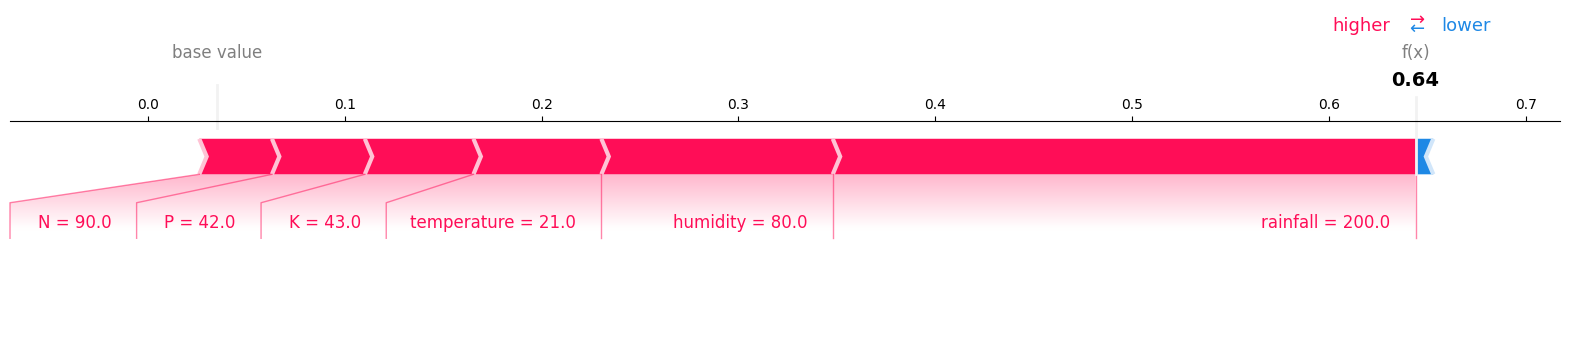

In [142]:
# Note: KernelExplainer is slower but works on Ensembles.
# We use a summary background dataset (kmeans) to speed it up.
import shap
import warnings
warnings.filterwarnings('ignore')

# Summarize background data (using 50 samples)
X_summary = shap.kmeans(X, 50)

# Create Explainer
explainer = shap.KernelExplainer(ensemble_model.predict_proba, X_summary)

# Calculate SHAP values for the specific farmer input
shap_values = explainer.shap_values(farmer_input)

# Visualization
print("\n📊 Feature Contribution Analysis:")

pred_index = crop_pred[0] # This is the index of the predicted class, e.g., 5 for coffee

# Correctly extract SHAP values for the predicted class from the 3D numpy array
# shap_values is typically of shape (n_samples, n_features, n_classes)
shap_values_for_plot = shap_values[0, :, pred_index]

# Safely extract expected_value for the predicted class
expected_value_for_plot = None
if isinstance(explainer.expected_value, np.ndarray) and explainer.expected_value.ndim == 1:
    # If expected_value is a 1D array, check its size
    if len(explainer.expected_value) > pred_index: # If it's multi-class and pred_index is valid
        expected_value_for_plot = explainer.expected_value[pred_index]
    elif len(explainer.expected_value) == 1: # If it's a 1-element array (as indicated by error)
        expected_value_for_plot = explainer.expected_value[0]
elif isinstance(explainer.expected_value, (int, float)): # If it's a scalar
    expected_value_for_plot = explainer.expected_value

if shap_values_for_plot is not None and expected_value_for_plot is not None:
    shap.force_plot(expected_value_for_plot, shap_values_for_plot, farmer_input, feature_names=X.columns, matplotlib=True)
else:
    print("Could not generate SHAP force plot due to unexpected SHAP output format.")

In [143]:
# Ask user for output language
print("\nSelect output language:")
print("en - English")
print("te - Telugu")
print("hi - Hindi")
print("ta - Tamil")

selected_lang = input("Enter language code: ").strip().lower()



Select output language:
en - English
te - Telugu
hi - Hindi
ta - Tamil
Enter language code: te


In [144]:
from googletrans import Translator

translator = Translator()


In [145]:
def translate_text(text, target_lang):
    if target_lang == "en":
        return text
    translated = translator.translate(text, dest=target_lang)
    return translated.text


In [146]:
def generate_shap_explanation(feature_df, crop):
    explanation = f"\n### Why {crop.upper()} was recommended (Explainable AI)\n\n"
    explanation += (
        "This recommendation is based on how your soil and climate conditions "
        "match the ideal requirements of the crop.\n\n"
    )

    explanation += "**Main reasons supporting this crop:**\n"
    for _, row in feature_df.head(3).iterrows():
        explanation += (
            f"- {row['feature'].capitalize()} value strongly supports {crop} "
            f"(impact score: {row['shap_value']:.2f})\n"
        )

    explanation += "\n**Factors that slightly reduce suitability:**\n"
    for _, row in feature_df.tail(3).sort_values(by="shap_value").iterrows():
        explanation += (
            f"- {row['feature'].capitalize()} has a lower influence "
            f"(impact score: {row['shap_value']:.2f})\n"
        )

    explanation += (
        "\nOverall, the positive factors outweigh the negative ones, "
        f"so {crop.upper()} is recommended as the best crop.\n"
    )

    return explanation


In [147]:
enhanced_shap_explanation = generate_shap_explanation(
    feature_importance_df,
    recommended_crop
)

full_report_markdown += "\n" + enhanced_shap_explanation


In [148]:
from googletrans import Translator
translator = Translator()

def translate_text_safe(text, target_lang):
    if target_lang == "en":
        return text

    try:
        result = translator.translate(text, dest=target_lang)
        if result is None or result.text is None:
            print("⚠️ Translation failed, returning original text")
            return text
        return result.text

    except Exception as e:
        print("⚠️ Translation error:", e)
        return text


In [149]:
def translate_large_text(text, target_lang, chunk_size=3000):
    if target_lang == "en":
        return text

    translated_chunks = []

    for i in range(0, len(text), chunk_size):
        chunk = text[i:i+chunk_size]
        translated_chunk = translate_text_safe(chunk, target_lang)
        translated_chunks.append(translated_chunk)

    return "\n".join(translated_chunks)


In [150]:
translated_report = translate_large_text(full_report_markdown, selected_lang)

print("\n🌍 FINAL REPORT IN SELECTED LANGUAGE:\n")
print(translated_report)



🌍 FINAL REPORT IN SELECTED LANGUAGE:

# Crop Recommendation Report

## Recommended Crop: RICE

## Suitable Mandals based on Groundwater
| district          | mandal                 |   value |
|:------------------|:-----------------------|--------:|
| ADILABAD          | Bela                   |    7.15 |
| ADILABAD          | Boath                  |    7.9  |
| BHADRADRI         | Allapalli              |    7.32 |
| BHADRADRI         | Annapureddipalle       |   12.74 |
| BHADRADRI         | Aswapuram              |    8.34 |
| BHADRADRI         | Aswapuram              |    8.5  |
| BHADRADRI         | Aswaraopeta            |   25.54 |
| BHADRADRI         | Aswaraopeta            |   27.32 |
| BHADRADRI         | Aswaraopeta            |   15.18 |
| BHADRADRI         | Burgampadu             |    9.17 |
| BHADRADRI         | Burgampadu             |    9.85 |
| BHADRADRI         | Chandrugonda           |   21.21 |
| BHADRADRI         | Chandrugonda           |    7.33 |
| BHADRA